In [1]:
!which python3

/usr/bin/python3


In [2]:
print("Python version:")

Python version:


In [1]:
%pip install lightning adversarial-robustness-toolbox[pytorch_image] umap-learn tsnecuda==3.0.1+cu122 -f https://tsnecuda.isx.ai/tsnecuda_stable.html

Looking in links: https://tsnecuda.isx.ai/tsnecuda_stable.html
Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import absolute_import, division, print_function, unicode_literals, annotations
import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any, Callable, TYPE_CHECKING
from dataclasses import dataclass

import h5py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.metrics import *

from tqdm.notebook import tqdm

from einops import rearrange
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import transforms
import torchvision.models as models
import torchmetrics
from torchvision.transforms.functional import gaussian_blur

import art
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent
from art.estimators.classification import PyTorchClassifier
from art.config import ART_NUMPY_DTYPE
from art.defences.preprocessor import SpatialSmoothingPyTorch

if TYPE_CHECKING:
    from art.utils import CLIP_VALUES_TYPE

from lightning import LightningModule


from joblib import delayed, Parallel
from scipy.optimize import minimize

import cv2

# Visualize the effect of the defense in preprocessing

## Dataset definition

In [3]:
class PCAMDataset(Dataset):
    """Optimized PCAM Dataset with lazy loading"""
    
    def __init__(self, input_file_path: str, label_file_path: str, 
                 transform=None, max_samples: Optional[int] = None):
        self.input_file_path = input_file_path
        self.label_file_path = label_file_path
        self.transform = transform
        self.max_samples = max_samples
        
        # Open files and keep references
        self.input_file = h5py.File(self.input_file_path, 'r')
        self.label_file = h5py.File(self.label_file_path, 'r')
        
        self.input_data = self.input_file["x"]
        self.label_data = self.label_file["y"]
        
        # Set length
        self.length = len(self.input_data)
        if max_samples is not None:
            self.length = min(max_samples, self.length)
            print(f"Using {max_samples}/{len(self.input_data)} samples")
            
    def __len__(self) -> int:
        return self.length
    
    def __getitem__(self, idx: int):
        if idx >= self.length:
            raise IndexError("Index out of range")
        
        # Load image and convert to PIL
        image = Image.fromarray(self.input_data[idx]).convert("RGB")
        label = int(self.label_data[idx, 0, 0, 0])
        
        if self.transform:
            image = self.transform(image)
            
        return image, label
    
    def __del__(self):
        # Close files when dataset is destroyed
        if hasattr(self, 'input_file'):
            self.input_file.close()
        if hasattr(self, 'label_file'):
            self.label_file.close()

In [4]:
# Configuration
DATA_ROOT = "/kaggle/input/metastatic-tissue-classification-patchcamelyon"

eval_transform = transforms.Compose([
    transforms.ToTensor(), # here they become [0, 1] due to torch backend with Pillow
])

test_dataset = PCAMDataset(
    input_file_path=os.path.join(DATA_ROOT, "pcam/test_split.h5"),
    label_file_path=os.path.join(DATA_ROOT, "Labels/Labels/camelyonpatch_level_2_split_test_y.h5"),
    transform=eval_transform,
    max_samples=100  
    )

Using 100/32768 samples


## Definition of the custom defense strategy

In [5]:
class JpegCompression(art.defences.preprocessor.preprocessor.Preprocessor):
    params = ["quality", "channels_first", "clip_values", "verbose"]

    def __init__(
        self,
        clip_values: "CLIP_VALUES_TYPE", # Should be (0,1) for JPEG part
        quality: int = 75,
        channels_first: bool = False,
        apply_fit: bool = True,
        apply_predict: bool = True,
        verbose: bool = False,
    ):
        super().__init__(is_fitted=True, apply_fit=apply_fit, apply_predict=apply_predict)
        self.quality = quality
        self.channels_first = channels_first
        self.clip_values = clip_values # Expected (0,1) for JPEG input
        self.verbose = verbose
        self._check_params()

    def _compress(self, x: np.ndarray, mode: str) -> np.ndarray:
        from PIL import Image
        from io import BytesIO

        tmp_jpeg = BytesIO()
        x_image = Image.fromarray(x, mode=mode)
        x_image.save(tmp_jpeg, format="jpeg", quality=self.quality)
        x_jpeg = np.array(Image.open(tmp_jpeg))
        tmp_jpeg.close()
        return x_jpeg

    def __call__(self, x: np.ndarray, y: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray | None]:
        # DISCLAIMER: The following clipping is necessary to ensure that the input to the JPEG compression
        # defence is in the [0, 1] range, as required by the JPEG compression algorithm. However, this introduction of clipping
        # may not be ideal for all use cases and introduces an approxximation error. We leave it to the user to decide whether this is acceptable.
        x = np.clip(x, self.clip_values[0], self.clip_values[1])  # Clip to [0, 1] range

        x_ndim = x.ndim
        if x_ndim not in [4, 5]:
            raise ValueError(
                "Unrecognized input dimension. JPEG compression can only be applied to image and video data."
            )

        if x.min() < 0.0:
            raise ValueError(
                "Negative values in input `x` detected. The JPEG compression defence requires unnormalized input."
            )

        # Swap channel index
        if self.channels_first and x_ndim == 4:
            # image shape NCHW to NHWC
            x = np.transpose(x, (0, 2, 3, 1))
        elif self.channels_first and x_ndim == 5:
            # video shape NCFHW to NFHWC
            x = np.transpose(x, (0, 2, 3, 4, 1))

        # insert temporal dimension to image data
        if x_ndim == 4:
            x = np.expand_dims(x, axis=1)

        # Convert into uint8
        if self.clip_values[1] == 1.0:
            x = x * 255
        x = x.astype("uint8")

        # Compress one image at a time
        x_jpeg = x.copy()
        for idx in np.ndindex(x.shape[:2]):
            if x.shape[-1] == 3:
                x_jpeg[idx] = self._compress(x[idx], mode="RGB")
            else:
                for i_channel in range(x.shape[-1]):
                    x_channel = x[idx[0], idx[1], ..., i_channel]
                    x_channel = self._compress(x_channel, mode="L")
                    x_jpeg[idx[0], idx[1], :, :, i_channel] = x_channel

        # Convert to ART dtype
        if self.clip_values[1] == 1.0:
            x_jpeg = x_jpeg / 255.0
        x_jpeg = x_jpeg.astype(ART_NUMPY_DTYPE)

        # remove temporal dimension for image data
        if x_ndim == 4:
            x_jpeg = np.squeeze(x_jpeg, axis=1)

        # Swap channel index
        if self.channels_first and x_jpeg.ndim == 4:
            # image shape NHWC to NCHW
            x_jpeg = np.transpose(x_jpeg, (0, 3, 1, 2))
        elif self.channels_first and x_ndim == 5:
            # video shape NFHWC to NCFHW
            x_jpeg = np.transpose(x_jpeg, (0, 4, 1, 2, 3))
        
        return x_jpeg, y

    def _check_params(self) -> None:
        if not isinstance(self.quality, int) or self.quality <= 0 or self.quality > 100:
            raise ValueError("Image quality must be a positive integer <= 100.")

        if len(self.clip_values) != 2:
            raise ValueError("'clip_values' should be a tuple of 2 floats or arrays containing the allowed data range.")

        if np.array(self.clip_values[0] >= self.clip_values[1]).any():
            raise ValueError("Invalid 'clip_values': min >= max.")

        if self.clip_values[0] != 0:
            raise ValueError("'clip_values' min value must be 0.")

        if self.clip_values[1] != 1.0 and self.clip_values[1] != 255:
            raise ValueError("'clip_values' max value must be either 1 or 255.")

        if not isinstance(self.verbose, bool):
            raise ValueError("The argument `verbose` has to be of type bool.")

In [6]:
class GaussianAugmentation(art.defences.preprocessor.preprocessor.Preprocessor):
    params = ["sigma", "verbose"]

    def __init__(
        self,
        clip_values: "CLIP_VALUES_TYPE" | None = None,
        sigma: float = 1.0,
        apply_fit: bool = True,
        apply_predict: bool = True,
        verbose: bool = False,
    ):
        super().__init__(is_fitted=True, apply_fit=apply_fit, apply_predict=apply_predict)
        self.sigma = sigma
        self.clip_values = clip_values
        self.verbose = verbose
        self._check_params()

    def __call__(self, x: np.ndarray, y: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray | None]:
        x_aug = np.random.normal(x, scale=self.sigma, size=x.shape).astype(ART_NUMPY_DTYPE)
        y_aug = y
        if self.clip_values is not None:
            x_aug = np.clip(x_aug, self.clip_values[0], self.clip_values[1])
        return x_aug, y_aug

    def _check_params(self) -> None:
        if not isinstance(self.sigma, float) or self.sigma <= 0:
            raise ValueError("Smoothing sigma must be a positive float.")
        if self.clip_values is not None:
            if len(self.clip_values) != 2:
                raise ValueError(
                    "clip_values should be a tuple of 2 floats with the allowed range."
                )
            if np.array(self.clip_values[0] >= self.clip_values[1]).any():
                raise ValueError("Invalid clip_values: min >= max.")


In [7]:
class TotalVarMininimization(art.defences.preprocessor.preprocessor.Preprocessor):
    params = ["prob", "norm", "lamb", "solver", "max_iter", "clip_values", "verbose"]

    def __init__(
        self,
        prob: float = 0.3,
        norm: int = 2,
        lamb: float = 0.5,
        solver: str = "L-BFGS-B",
        max_iter: int = 10,
        clip_values: "CLIP_VALUES_TYPE" | None = None,
        apply_fit: bool = False,
        apply_predict: bool = True,
        verbose: bool = False,
    ):
        """
        Create an instance of total variance minimization.

        :param prob: Probability of the Bernoulli distribution.
        :param norm: The norm (positive integer).
        :param lamb: The lambda parameter in the objective function.
        :param solver: Current support: `L-BFGS-B`, `CG`, `Newton-CG`.
        :param max_iter: Maximum number of iterations when performing optimization.
        :param clip_values: Tuple of the form `(min, max)` representing the minimum and maximum values allowed
               for features.
        :param apply_fit: True if applied during fitting/training.
        :param apply_predict: True if applied during predicting.
        :param verbose: Show progress bars.
        """
        super().__init__(is_fitted=True, apply_fit=apply_fit, apply_predict=apply_predict)
        self.prob = prob
        self.norm = norm
        self.lamb = lamb
        self.solver = solver
        self.max_iter = max_iter
        self.clip_values = clip_values
        self.verbose = verbose
        self._check_params()

    def __call__(self, x: np.ndarray, y: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray | None]:
        """
        Apply total variance minimization to sample `x`.

        :param x: Sample to compress with shape `(batch_size, width, height, depth)`.
        :param y: Labels of the sample `x`. This function does not affect them in any way.
        :return: Similar samples.
        """
        if len(x.shape) == 2:
            raise ValueError(
                "Feature vectors detected. Variance minimization can only be applied to data with spatial dimensions."
            )
        x_preproc = x.copy()

        def _optimize_channel(x_i, channel_idx):
            """Optimize a single channel of an image."""
            mask = (np.random.rand(*x_i.shape) < self.prob).astype("int")
            res = minimize(
                self._loss_func,
                x_i[:, :, channel_idx].flatten(),
                (x_i[:, :, channel_idx], mask[:, :, channel_idx], self.norm, self.lamb),
                method=self.solver,
                jac=self._deri_loss_func,
                options={"maxiter": self.max_iter},
            )
            return channel_idx, np.reshape(res.x, x_i[:, :, channel_idx].shape)

        def _process_image(i, x_i):
            """Process a single image with parallel channel optimization."""
            z_min = x_i.copy()
            
            # Parallelize across channels
            results = Parallel(n_jobs=-1)(
                delayed(_optimize_channel)(x_i, channel_idx) 
                for channel_idx in range(x_i.shape[2])
            )
            
            # Update channels with optimized results
            for channel_idx, optimized_channel in results:
                z_min[:, :, channel_idx] = optimized_channel
                
            return i, z_min

        # Parallelize across batch items
        batch_results = Parallel(n_jobs=-1)(
            delayed(_process_image)(i, x_i) 
            for i, x_i in enumerate(tqdm(x_preproc, desc="Variance minimization", disable=not self.verbose))
        )
        
        # Update the preprocessed data
        for i, z_min in batch_results:
            x_preproc[i] = z_min

        if self.clip_values is not None:
            np.clip(x_preproc, self.clip_values[0], self.clip_values[1], out=x_preproc)

        return x_preproc.astype(ART_NUMPY_DTYPE), y

    @staticmethod
    def _loss_func(z_init: np.ndarray, x: np.ndarray, mask: np.ndarray, norm: int, lamb: float) -> float:
        """
        Loss function to be minimized.

        :param z_init: Initial guess.
        :param x: Original image.
        :param mask: A matrix that decides which points are kept.
        :param norm: The norm (positive integer).
        :param lamb: The lambda parameter in the objective function.
        :return: Loss value.
        """
        res = np.sqrt(np.power(z_init - x.flatten(), 2).dot(mask.flatten()))
        z_init = np.reshape(z_init, x.shape)
        res += lamb * np.linalg.norm(z_init[1:, :] - z_init[:-1, :], norm, axis=1).sum()
        res += lamb * np.linalg.norm(z_init[:, 1:] - z_init[:, :-1], norm, axis=0).sum()

        return res

    @staticmethod
    def _deri_loss_func(z_init: np.ndarray, x: np.ndarray, mask: np.ndarray, norm: int, lamb: float) -> float:
        """
        Derivative of loss function to be minimized.

        :param z_init: Initial guess.
        :param x: Original image.
        :param mask: A matrix that decides which points are kept.
        :param norm: The norm (positive integer).
        :param lamb: The lambda parameter in the objective function.
        :return: Derivative value.
        """
        # First compute the derivative of the first component of the loss function
        nor1 = np.sqrt(np.power(z_init - x.flatten(), 2).dot(mask.flatten()))
        nor1 = max(nor1, 1e-06)
        der1 = ((z_init - x.flatten()) * mask.flatten()) / (nor1 * 1.0)

        # Then compute the derivative of the second component of the loss function
        z_init = np.reshape(z_init, x.shape)

        if norm == 1:
            z_d1 = np.sign(z_init[1:, :] - z_init[:-1, :])
            z_d2 = np.sign(z_init[:, 1:] - z_init[:, :-1])
        else:
            z_d1_norm = np.power(np.linalg.norm(z_init[1:, :] - z_init[:-1, :], norm, axis=1), norm - 1)
            z_d2_norm = np.power(np.linalg.norm(z_init[:, 1:] - z_init[:, :-1], norm, axis=0), norm - 1)
            z_d1_norm[z_d1_norm < 1e-6] = 1e-6
            z_d2_norm[z_d2_norm < 1e-6] = 1e-6
            z_d1_norm = np.repeat(z_d1_norm[:, np.newaxis], z_init.shape[1], axis=1)
            z_d2_norm = np.repeat(z_d2_norm[np.newaxis, :], z_init.shape[0], axis=0)
            z_d1 = norm * np.power(z_init[1:, :] - z_init[:-1, :], norm - 1) / z_d1_norm
            z_d2 = norm * np.power(z_init[:, 1:] - z_init[:, :-1], norm - 1) / z_d2_norm

        der2 = np.zeros(z_init.shape)
        der2[:-1, :] -= z_d1
        der2[1:, :] += z_d1
        der2[:, :-1] -= z_d2
        der2[:, 1:] += z_d2
        der2 = lamb * der2.flatten()

        # Total derivative
        return der1 + der2

    def _check_params(self) -> None:
        if not isinstance(self.prob, (float, int)) or self.prob < 0.0 or self.prob > 1.0:
            raise ValueError("Probability must be between 0 and 1.")

        if not isinstance(self.norm, int) or self.norm <= 0:
            raise ValueError("Norm must be a positive integer.")

        if self.solver not in ("L-BFGS-B", "CG", "Newton-CG"):
            raise ValueError("Current support only L-BFGS-B, CG, Newton-CG.")

        if not isinstance(self.max_iter, int) or self.max_iter <= 0:
            raise ValueError("Number of iterations must be a positive integer.")

        if self.clip_values is not None:

            if len(self.clip_values) != 2:
                raise ValueError("`clip_values` should be a tuple of 2 floats containing the allowed data range.")

            if np.array(self.clip_values[0] >= self.clip_values[1]).any():
                raise ValueError("Invalid `clip_values`: min >= max.")

        if not isinstance(self.verbose, bool):
            raise ValueError("The argument `verbose` has to be of type bool.")

In [8]:
class GaussianSmoothing(art.defences.preprocessor.preprocessor.Preprocessor):
    params = ["kernel_size", "sigma", "visualize"]

    def __init__(
        self,
        kernel_size: list[int],
        sigma: Optional[list[float]] = None,
        apply_fit: bool = True,
        apply_predict: bool = True,
        visualize: bool = False
    ):
        super().__init__(is_fitted=True, apply_fit=apply_fit, apply_predict=apply_predict)
        self.kernel_size = kernel_size
        self.sigma = sigma
        self.visualize = visualize
        self._check_params()

    def __call__(self, x: np.ndarray, y: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray | None]:

        """
        Applies Gaussian smoothing to the input `x`.
        """
        # Convert to tensor if not already
        if not isinstance(x, torch.Tensor):
            x = torch.from_numpy(x)

        x_smoothed = gaussian_blur(x, kernel_size=self.kernel_size, sigma=self.sigma)

        if self.visualize:
            # Visualize the first image in the batch
            if x_smoothed.ndim == 4:
                plt.figure(figsize=(6, 6))
                plt.subplot(1, 2, 1)
                img = x[0].permute(1, 2, 0).numpy()
                plt.imshow(img)
                plt.axis('off')
                plt.title("Original Image")
                plt.subplot(1, 2, 2)
                img = x_smoothed[0].permute(1, 2, 0).numpy()
                plt.imshow(img)
                plt.axis('off')
                plt.title("Smoothed Image")
                plt.show()
                
        return x_smoothed.numpy().astype(ART_NUMPY_DTYPE), y
        
    def _check_params(self) -> None:
        if not isinstance(self.kernel_size, list) or len(self.kernel_size) != 2:
            raise ValueError("Kernel size must be a list of two integers [height, width].")
        if not all(isinstance(k, int) and k > 0 for k in self.kernel_size):
            raise ValueError("Kernel size values must be positive integers.")
        if self.sigma is not None and (not isinstance(self.sigma, list) or len(self.sigma) != 2):
            raise ValueError("Sigma must be a list of two floats [sigma_h, sigma_w].")
        if self.sigma is not None and not all(isinstance(s, (float, int)) for s in self.sigma):
            raise ValueError("Sigma values must be floats or integers.")

## Visualize the effects of the defense strategy on clean images

In [9]:
image, label = test_dataset.__getitem__(0)

### Gaussian Smoothing

In [ ]:
pr

In [11]:
smoother = GaussianSmoothing(sigma=[float(s),float(s)], kernel_size=[3, 3], visualize=True)

image_smoothed, _ = smoother(image.unsqueeze(0), None)

plt.figure(figsize=(6, 6))
plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0).numpy())
plt.axis('off')
plt.title("Original Image")
plt.subplot(1, 2, 2)
plt.imshow(image_smoothed[0])


NameError: name 's' is not defined

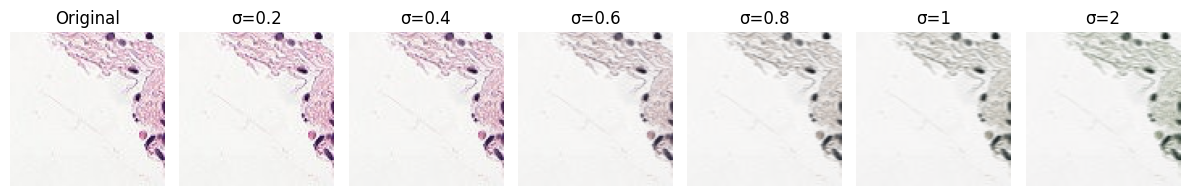

In [39]:
sigma_values = [0.2, 0.4, 0.6, 0.8, 1, 2] # Using slightly different values to better see the effect

img = image.numpy().transpose(1, 2, 0)

plt.figure(figsize=(12, 4))
plt.subplot(1, len(sigma_values) + 1, 1)
plt.title("Original")
plt.axis("off")
plt.imshow(img)

for i, s in enumerate(sigma_values):
    
    # Use the corrected GaussianSmoothing class
    smoother = GaussianSmoothing(sigma=[float(s),float(s)], kernel_size=[3, 3], visualize=False)
    
    # The preprocessor expects a batch, so we add a dimension at the start
    # Input shape: (1, height, width, channels)
    #img_batch = np.expand_dims(img, axis=0)
    
    # Apply the smoothing
    smoothed_batch, _ = smoother(img_batch)
    
    # Get the single image back from the batch
    img_smoothed = smoothed_batch[0]

    plt.subplot(1, len(sigma_values) + 1, i + 2)
    plt.axis("off")
    plt.title(f"σ={s}")
    plt.imshow(img_smoothed)

plt.tight_layout()
plt.show()

### Gaussian Augmentation

In [ ]:
sigma_values = [0.2, 0.4, 0.6, 0.8, 1, 2] # Using slightly different values to better see the effect

img = image.numpy().transpose(1, 2, 0)

plt.figure(figsize=(12, 4))
plt.subplot(1, len(sigma_values) + 1, 1)
plt.title("Original")
plt.axis("off")
plt.imshow(img)

for i, s in enumerate(sigma_values):
    
    # Use the corrected GaussianSmoothing class
    smoother = GaussianSmoothing(sigma=[float(s),float(s)], kernel_size=[3, 3])
    
    # The preprocessor expects a batch, so we add a dimension at the start
    # Input shape: (1, height, width, channels)
    img_batch = np.expand_dims(img, axis=0)
    
    # Apply the smoothing
    smoothed_batch, _ = smoother(img_batch)
    
    # Get the single image back from the batch
    img_smoothed = smoothed_batch[0]

    plt.subplot(1, len(sigma_values) + 1, i + 2)
    plt.axis("off")
    plt.title(f"σ={s}")
    plt.imshow(img_smoothed)

plt.tight_layout()
plt.show()

### Spatial smoothing

### Jpeg compression

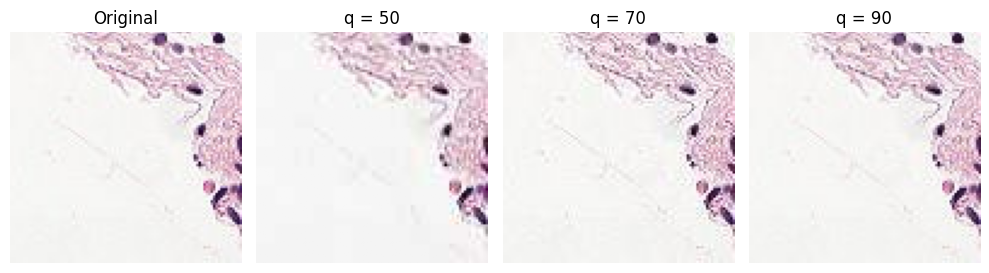

In [17]:
#quality value to test
q_values = [50, 70, 90]

img_jpeg = image.numpy().transpose(1, 2, 0)

plt.figure(figsize=(10, 4))
plt.subplot(1, len(q_values) + 1, 1)
plt.title("Original")
plt.imshow(img_jpeg)
plt.axis("off")

for i, q in enumerate(q_values):
    jpeg_comp = JpegCompression(
        clip_values=(0, 1),
        quality=q,
        channels_first=False,
        verbose=True
    )
    x_comp, _ = jpeg_comp(np.expand_dims(img_jpeg, axis=0))
    img_comp = x_comp[0]

    plt.subplot(1, len(q_values) + 1, i + 2)
    plt.title(f"q = {q}")
    plt.imshow(img_comp)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Total Variance Minimization

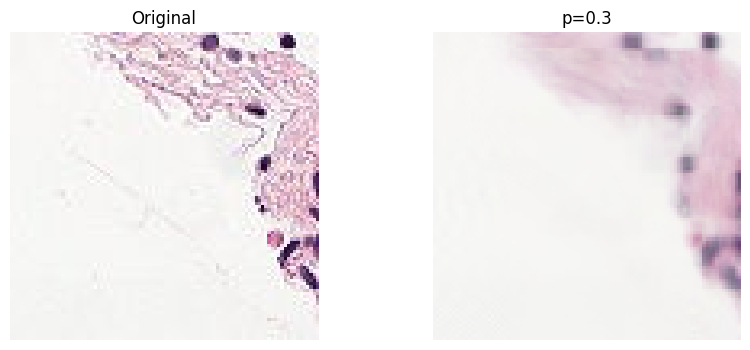

In [26]:
p_values = [0.3]
img = image.numpy().transpose(1, 2, 0)

plt.figure(figsize=(10, 4))
plt.subplot(1, len(p_values) + 1, 1)
plt.title("Original")
plt.axis("off")
plt.imshow(img)

for i, p in enumerate(p_values):
    tv_comp = TotalVarMininimization(
        prob=p,
        norm=2,
        lamb=0.5,
        # ... other params
    )
    x_tv, _ = tv_comp(np.expand_dims(img, axis=0))
    img_tvm_small = x_tv[0]

    # --- FIX IS HERE ---
    # Upsample the small processed image back to the original size
    img_tvm_resized = cv2.resize(
        img_tvm_small,
        (img.shape[1], img.shape[0]), # (width, height) for cv2
        interpolation=cv2.INTER_NEAREST # Use INTER_NEAREST to keep the blocky look
                                        # Use cv2.INTER_CUBIC for a smoother look
    )

    plt.subplot(1, len(p_values) + 1, i + 2)
    plt.title(f"p={p}")
    plt.axis("off")
    # Display the resized image
    plt.imshow(img_tvm_resized)

plt.show()

# Attacks 

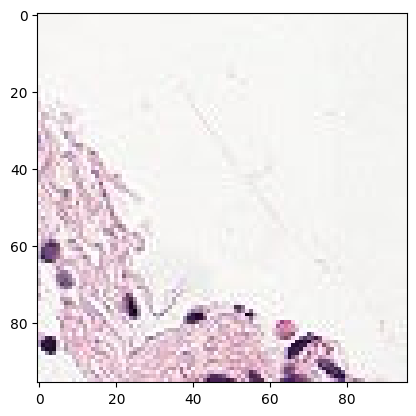

In [9]:
from PIL import Image

import matplotlib.pyplot as plt
import numpy as np

jpeg_defence = JpegCompressionRenorm(
    clip_values=(0.0, 1.0),
    imagenet_mean=[0.485, 0.456, 0.406],
    imagenet_std=[0.229, 0.224, 0.225],
    quality=50,
    channels_first=False,
    verbose=True
)

image, label = test_dataset.__getitem__(0)

image = image.numpy()

imgplot = plt.imshow(image.T)


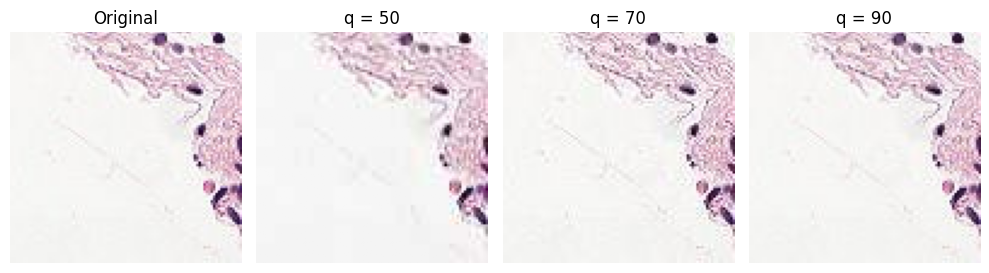

In [30]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt

# Carica un'immagine di esempio
img, label = test_dataset.__getitem__(0)
img = img.numpy().transpose(1, 2, 0)

# Valori di "quality" da testare
q_values = [50, 70, 90]

plt.figure(figsize=(10, 4))
plt.subplot(1, len(q_values) + 1, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

# Mostra la stessa immagine con diversi livelli di compressione JPEG
for i, q in enumerate(q_values):
    jpeg_comp = JpegCompression(
        clip_values=(0, 1),
        quality=q,
        channels_first=False,
        verbose=True
    )
    x_comp, _ = jpeg_comp(np.expand_dims(img, axis=0))
    img_comp = x_comp[0]

    plt.subplot(1, len(q_values) + 1, i + 2)
    plt.title(f"q = {q}")
    plt.imshow(img_comp)
    plt.axis("off")

plt.tight_layout()
plt.show()

MIN AND MAX OF INPUT X: 0.0 1.0


JPEG compression: 0it [00:00, ?it/s]

MIN AND MAX OF INPUT X: 0.0 1.0


JPEG compression: 0it [00:00, ?it/s]

MIN AND MAX OF INPUT X: 0.0 1.0


JPEG compression: 0it [00:00, ?it/s]

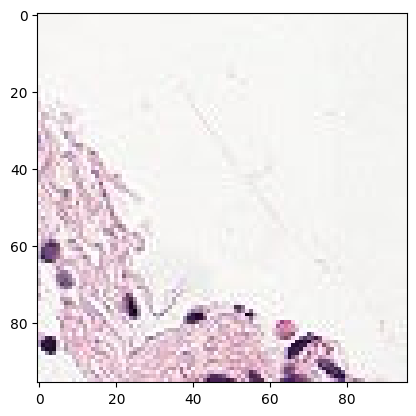

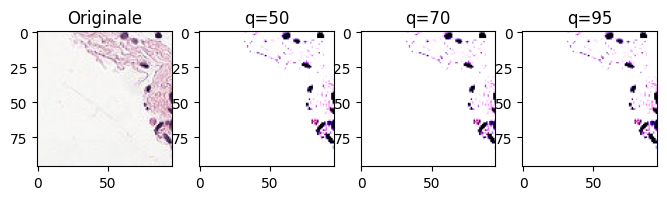

In [11]:
img, label = test_dataset.__getitem__(0)

img = img.numpy()  # Convert to numpy array if needed
img = img.transpose(1, 2, 0)  # Convert from CHW to HWC format if needed

imgplot = plt.imshow(image.T)

plt.figure(figsize=(8, 4))


q_values = [50, 70, 95]  # Qualities to test

nplots = len(q_values)  # Number of subplots
plt.subplot(1, nplots+1, 1)
plt.title("Originale")
plt.imshow(img)

for i in range(len(q_values)):

    q = q_values[i]

    jpeg_defence = JpegCompressionRenorm(
        clip_values=(0.0, 1.0),
        imagenet_mean=[0.485, 0.456, 0.406],
        imagenet_std=[0.229, 0.224, 0.225],
        quality=q,
        channels_first=False,
        verbose=True
    )

    x_compressed, _ = jpeg_comp(np.expand_dims(img, axis=0))
    img_compressed = x_compressed[0]

    plt.subplot(1, nplots+1, i+2)
    plt.title(f"q={q}")
    plt.imshow(img_compressed)

plt.show()

Variance minimization:   0%|          | 0/1 [00:00<?, ?it/s]

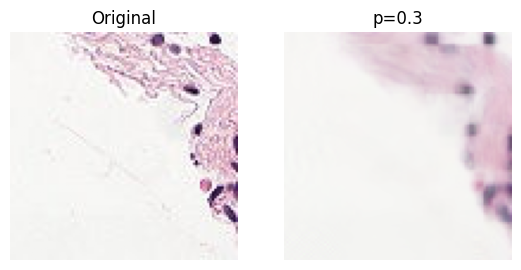

In [12]:
# Carica un batch di dati
img, label = test_dataset.__getitem__(0)

# Converte in NumPy e da CHW a HWC se necessario
img = img.numpy()
img = img.transpose(1, 2, 0)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.axis("off")
plt.imshow(img)

p_values = [0.3]

for i, p in enumerate(p_values):
    
    tv_comp = TotalVarMininimization(
        prob=p,
        norm=2,
        lamb=0.5,
        solver="L-BFGS-B",
        max_iter=10,
        clip_values=(0, 1),
        apply_predict=True,
        verbose=True
    )
    x_tv, _ = tv_comp(np.expand_dims(img, axis=0))
    img_tv = x_tv[0]

    plt.subplot(1, 3, i+2)
    plt.axis("off")
    plt.title(f"p={p}")
    plt.imshow(img_tv)

plt.show()

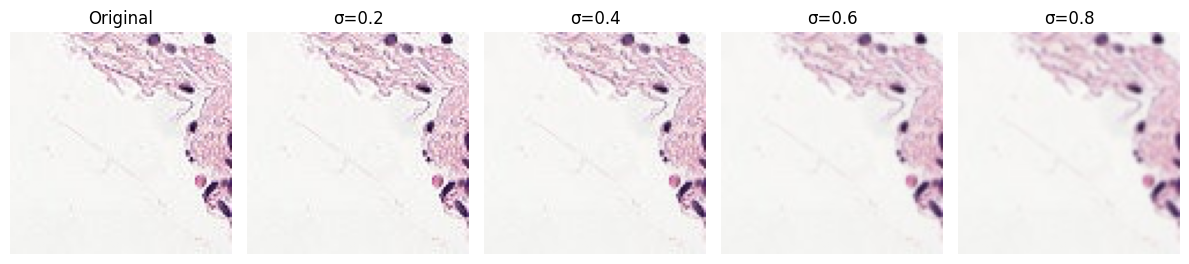

In [13]:
# Assuming 'test_dataset' is loaded as before
img, label = test_dataset.__getitem__(0)

# Converte in NumPy ed da CHW (torch) a HWC (matplotlib)
img = img.numpy().transpose(1, 2, 0)

plt.figure(figsize=(12, 4))
plt.subplot(1, 5, 1)
plt.title("Original")
plt.axis("off")
plt.imshow(img)

# Different sigma values for blurring
sigma_values = [0.2, 0.4, 0.6, 0.8] # Using slightly different values to better see the effect

for i, s in enumerate(sigma_values):
    
    # Use the corrected GaussianSmoothing class
    smoother = GaussianSmoothing(sigma=s)
    
    # The preprocessor expects a batch, so we add a dimension at the start
    # Input shape: (1, height, width, channels)
    img_batch = np.expand_dims(img, axis=0)
    
    # Apply the smoothing
    smoothed_batch, _ = smoother(img_batch)
    
    # Get the single image back from the batch
    img_smoothed = smoothed_batch[0]

    plt.subplot(1, 5, i+2)
    plt.axis("off")
    plt.title(f"σ={s}")
    plt.imshow(img_smoothed)

plt.tight_layout()
plt.show()

Filter 3x3: Processed image shape is (3, 96, 96)
Filter 5x5: Processed image shape is (3, 96, 96)


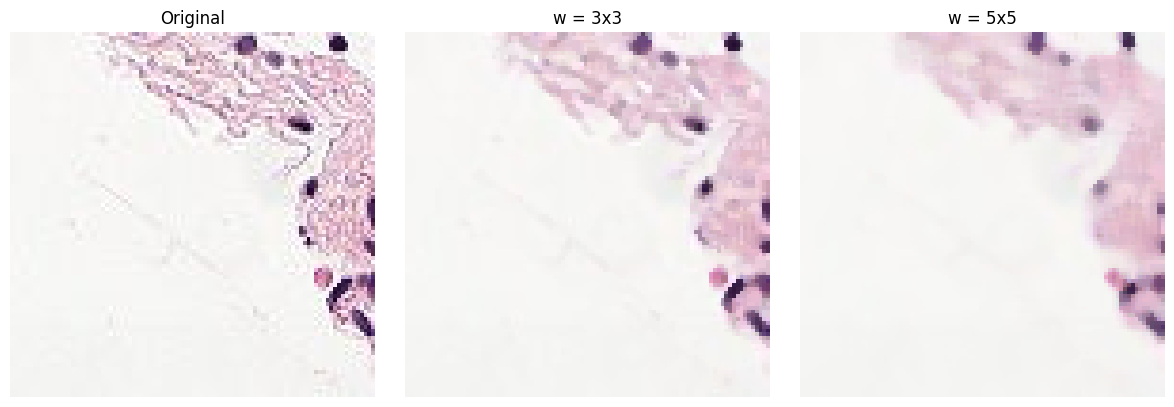

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from art.defences.preprocessor import SpatialSmoothingPyTorch

# --- Assuming test_dataset is already loaded ---

# Esempio: carica un campione dal dataset
img, label = test_dataset.__getitem__(0) # img is a Tensor [C, H, W]

# We need the original image for plotting, so we create a version for imshow
# which expects (H, W, C)
img_for_plot = img.numpy().transpose(1, 2, 0)

# The defense needs the input as a NumPy array, but in the original [C, H, W] format.
img_for_defense = img.numpy() 

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img_for_plot)
plt.axis("off")

filter_sizes = [3, 5]

for i, fs in enumerate(filter_sizes):
    # Definisci la difesa con SpatialSmoothingPyTorch
    # channels_first=True expects input shape (N, C, H, W)
    smoothing = SpatialSmoothingPyTorch(window_size=fs, channels_first=True)

    # Applica lo smoothing. 
    # Add the batch dimension to our [C, H, W] image.
    # The input shape is now (1, C, H, W), which is correct.
    x_smooth, _ = smoothing(np.expand_dims(img_for_defense, axis=0))
    
    # x_smooth is a batch of smoothed images with shape (1, C, H, W)
    # Get the first (and only) image from the batch.
    processed_img_chw = x_smooth[0]

    print(f"Filter {fs}x{fs}: Processed image shape is {processed_img_chw.shape}") # Should be (C, H, W)

    # For plotting with plt.imshow, we must transpose from [C, H, W] to [H, W, C]
    processed_img_hwc = processed_img_chw.transpose(1, 2, 0)

    plt.subplot(1, 3, i + 2)
    plt.title(f"w = {fs}x{fs}")
    plt.imshow(processed_img_hwc)
    plt.axis("off")

plt.tight_layout()
plt.show()

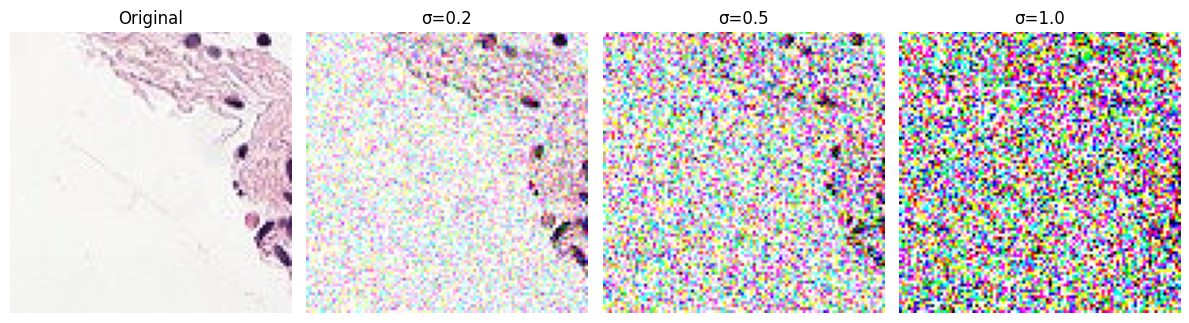

In [16]:
# ...existing code...
# Esempio: carica un campione dal dataset
img, label = test_dataset.__getitem__(0)  # img is a Tensor [C, H, W]

# We need the original image for plotting, so we create a version for imshow
# which expects (H, W, C)
img_for_plot = img.numpy().transpose(1, 2, 0)

# The defense needs the input as a NumPy array, but in the original [C, H, W] format.
img_for_defense = img.numpy()

plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.title("Original")
plt.imshow(img_for_plot)
plt.axis("off")

sigma = [0.2, 0.5, 1.0]

for i, s in enumerate(sigma):
    smoothing = AddedGaussianNoise(sigma=s)

    x_smooth, _ = smoothing(np.expand_dims(img_for_defense, axis=0))
    processed_img_chw = x_smooth[0]


    processed_img_hwc = processed_img_chw.transpose(1, 2, 0)

    plt.subplot(1, 4, i + 2)
    plt.title(f"σ={s}")
    plt.imshow(processed_img_hwc)
    plt.axis("off")

plt.tight_layout()
plt.show()
# ...existing code...

# Visualize the effect of the attacks

In [17]:
class ResNet18Classifier(LightningModule):
    def __init__(self, num_classes: int = 2, label_smoothing: float = 0.0):
        super().__init__()
        self.model = models.resnet18(weights='DEFAULT')
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        self.num_classes = num_classes
        
        self.criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

        self.train_acc = torchmetrics.Accuracy("binary", num_classes=num_classes)
        self.train_auroc = torchmetrics.AUROC("binary", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy("binary", num_classes=num_classes)
        self.val_auroc = torchmetrics.AUROC("binary", num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy("binary", num_classes=num_classes)
        self.test_auroc = torchmetrics.AUROC("binary", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def _step(self, batch, stage: str):
        images, labels = batch

        outputs = self(images)
        loss = self.criterion(outputs, labels)
        preds = torch.argmax(outputs, dim=1)
        probs = F.softmax(outputs, dim=1)

        if stage == "train":
            self.train_acc(preds, labels)
            self.train_auroc(probs, labels)
        elif stage == "val":
            self.val_acc(preds, labels)
            self.val_auroc(probs, labels)
        elif stage == "test":
            self.test_acc(preds, labels)
            self.test_auroc(probs, labels)
        else:
            raise ValueError(f"Unknown stage: {stage}")
        
        self.log(f"{stage}_loss", loss, on_step=False, on_epoch=True, prog_bar=True)        
        return loss

    def training_step(self, batch, batch_idx):
        return self._step(batch, "train")
    def validation_step(self, batch, batch_idx):
        return self._step(batch, "val")
    def test_step(self, batch, batch_idx):
        return self._step(batch, "test")

    def on_train_epoch_end(self):
        self.log("train_acc", self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_auroc", self.train_auroc, on_step=False, on_epoch=True, prog_bar=True)
        self.train_acc.reset()
        self.train_auroc.reset()
    
    def on_validation_epoch_end(self):
        self.log("val_acc", self.val_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_auroc", self.val_auroc, on_step=False, on_epoch=True, prog_bar=True)
        self.val_acc.reset()
        self.val_auroc.reset()

    def on_test_epoch_end(self):
        self.log("test_acc", self.test_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_auroc", self.test_auroc, on_step=False, on_epoch=True, prog_bar=True)
        self.test_acc.reset()
        self.test_auroc.reset()

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=1e-3, weight_decay=0.05)
        
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.1, patience=5
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1,
            },
        }
        
    def freeze_backbone(self):
        for param in self.model.parameters():
            param.requires_grad = False
        for param in self.model.fc.parameters():  # Keep classifier trainable
            param.requires_grad = True

    def unfreeze_backbone(self):
        for param in self.model.parameters():
            param.requires_grad = True

In [18]:
# Configuration
DATA_ROOT = "/kaggle/input/metastatic-tissue-classification-patchcamelyon"

# There are two model checkpoints available:
# 1. without data augmentation: https://www.kaggle.com/models/electroduck/hermes_resnet_18/pyTorch/no_augmentation_lightning/1/reduced_dataset_no_data_augmentation.ckpt
# 2. with data augmentation: https://www.kaggle.com/models/electroduck/hermes_resnet_18/pyTorch/lightning/2/reduced_dataset_10ep.ckpt
MODEL_PATH = "/kaggle/input/hermes_resnet_18/pytorch/lightning/2/reduced_dataset_10ep.ckpt"

BATCH_SIZE = 64

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from art.estimators.classification import PyTorchClassifier
from art.defences.preprocessor import JpegCompression

# Carica il tuo modello Lightning
resnet_model = ResNet18Classifier.load_from_checkpoint(MODEL_PATH)
resnet_model.eval()

# Crea un optimizer compatibile con il tuo modello
optimizer = optim.AdamW(resnet_model.parameters(), lr=1e-3, weight_decay=0.05)

# Crea il PyTorchClassifier
classifier = PyTorchClassifier(
    model=resnet_model,                       # Il tuo modello Lightning
    loss=nn.CrossEntropyLoss(),               # Funzione di loss (la stessa definita in ResNet18Classifier)
    optimizer=optimizer,                      # Optimizer 
    input_shape=(3, 96, 96),                # Specifica la shape di input (C, H, W)
    nb_classes=resnet_model.num_classes,      # Numero di classi
    channels_first=True,                      # True se il modello si aspetta input NCHW
    clip_values=(0, 1),                       # Range di normalizzazione (modificalo se necessario)
    preprocessing_defences=[JpegCompression(
        quality=50,  # Imposta la qualità JPEG
        clip_values=(0, 1),  # Assicurati che i valori siano tra 0 e 1
        channels_first=True,  # True se il modello si aspetta input NCHW
        apply_fit=False,  # Non applicare durante il fitting
        apply_predict=True,  # Applica durante la previsione
    )],
    device_type='cuda' if torch.cuda.is_available() else 'cpu'
)

print("ART PyTorchClassifier creato con successo!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 141MB/s]


ART PyTorchClassifier creato con successo!


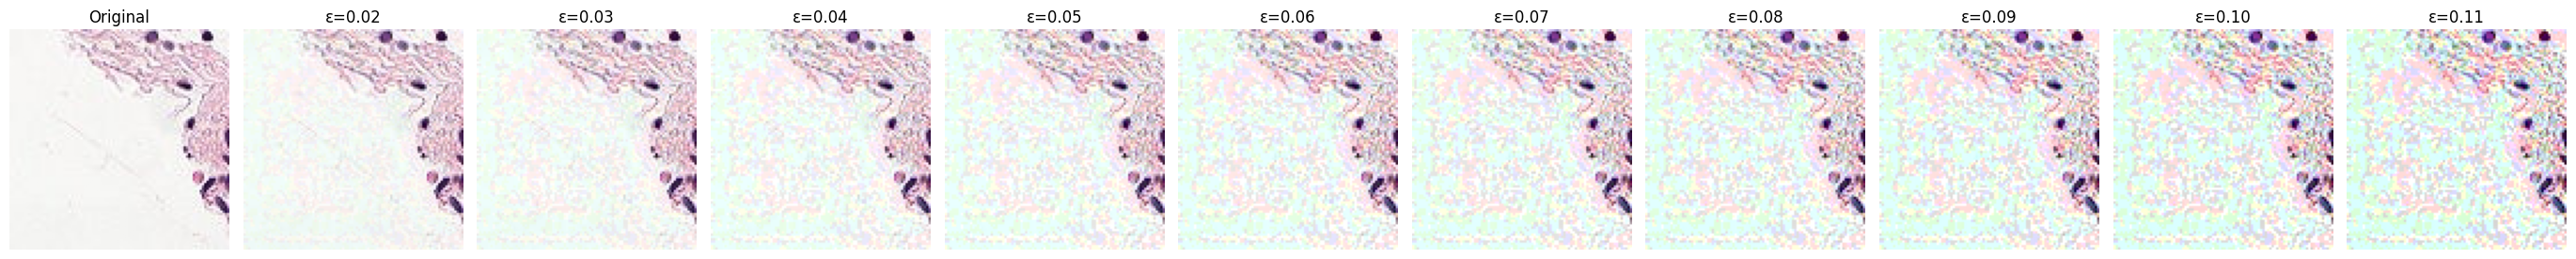

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from art.attacks.evasion import FastGradientMethod

#import the pgd method
from art.attacks.evasion import ProjectedGradientDescent

# Supponendo che 'classifier' e 'test_dataset' siano già definiti.

# Carichiamo un'immagine di test
img, label = test_dataset.__getitem__(0)

# Prepariamo le versioni per il plot e per l'attacco
img_for_plot = img.numpy().transpose(1, 2, 0)
x_input = np.expand_dims(img.numpy(), axis=0) # (1, C, H, W)

# Diversi valori di epsilon
epsilons = np.arange(0.02, 0.12, 0.01)

# Impostiamo la figura
# The number of plots is len(epsilons) + 1 for the original
num_plots = len(epsilons) + 1
plt.figure(figsize=(num_plots * 2.5, 3)) # Adjust figsize dynamically

# Visualizza l’immagine originale
plt.subplot(1, num_plots, 1)
plt.title("Original")
plt.imshow(img_for_plot)
plt.axis("off")

# Genera e mostra gli esempi avversari per ogni epsilon
for i, eps in enumerate(epsilons):
    
    # --- THE CRITICAL FIX IS HERE ---
    # Creiamo una NUOVA istanza dell'attacco per ogni valore di epsilon.
    # Questo assicura che venga usato il valore di `eps` corretto.
    fgsm_attack = FastGradientMethod(estimator=classifier, eps=eps)
    
    # Genera l'attacco. Non c'è bisogno di passare 'eps' qui.
    x_adv = fgsm_attack.generate(x=x_input)
    
    # Riconverti in [H, W, C] per visualizzarlo
    adv_img_np = x_adv[0].transpose(1, 2, 0)

    # Clippa i valori per la visualizzazione corretta
    adv_img_clipped = np.clip(adv_img_np, 0, 1)
    
    # --- FIX PER IL TITOLO ---
    # Usiamo un f-string per formattare il float a due cifre decimali
    plt.subplot(1, num_plots, i + 2)
    plt.title(f"ε={eps:.2f}") # e.g., formats 0.0600... to "0.06"
    plt.imshow(adv_img_clipped)
    plt.axis("off")

plt.tight_layout()
plt.show()

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/100 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/100 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

...

PGD - Iterations:   0%|          | 0/100 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/100 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/100 [00:00<?, ?it/s]

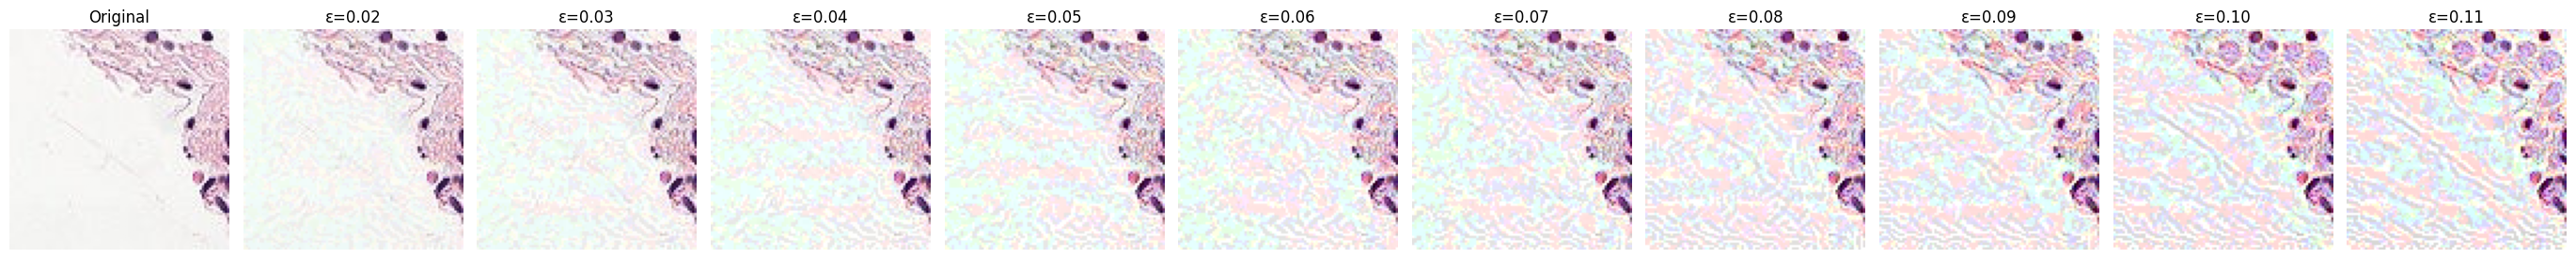

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from art.attacks.evasion import FastGradientMethod

#import the pgd method
from art.attacks.evasion import ProjectedGradientDescent

# Supponendo che 'classifier' e 'test_dataset' siano già definiti.

# Carichiamo un'immagine di test
img, label = test_dataset.__getitem__(0)

# Prepariamo le versioni per il plot e per l'attacco
img_for_plot = img.numpy().transpose(1, 2, 0)
x_input = np.expand_dims(img.numpy(), axis=0) # (1, C, H, W)

# Diversi valori di epsilon
epsilons = np.arange(0.02, 0.12, 0.01)

# Impostiamo la figura
# The number of plots is len(epsilons) + 1 for the original
num_plots = len(epsilons) + 1
plt.figure(figsize=(num_plots * 2.5, 3)) # Adjust figsize dynamically

# Visualizza l’immagine originale
plt.subplot(1, num_plots, 1)
plt.title("Original")
plt.imshow(img_for_plot)
plt.axis("off")

# Genera e mostra gli esempi avversari per ogni epsilon
for i, eps in enumerate(epsilons):
    
    # --- THE CRITICAL FIX IS HERE ---
    # Creiamo una NUOVA istanza dell'attacco per ogni valore di epsilon.
    # Questo assicura che venga usato il valore di `eps` corretto.
    fgsm_attack = ProjectedGradientDescent(estimator=classifier, eps=eps)
    
    # Genera l'attacco. Non c'è bisogno di passare 'eps' qui.
    x_adv = fgsm_attack.generate(x=x_input)
    
    # Riconverti in [H, W, C] per visualizzarlo
    adv_img_np = x_adv[0].transpose(1, 2, 0)

    # Clippa i valori per la visualizzazione corretta
    adv_img_clipped = np.clip(adv_img_np, 0, 1)
    
    # --- FIX PER IL TITOLO ---
    # Usiamo un f-string per formattare il float a due cifre decimali
    plt.subplot(1, num_plots, i + 2)
    plt.title(f"ε={eps:.2f}") # e.g., formats 0.0600... to "0.06"
    plt.imshow(adv_img_clipped)
    plt.axis("off")

plt.tight_layout()
plt.show()